In [1]:
!pip install ultralytics
!pip install efficientnet_pytorch timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.5/974.5 kB 17.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16424 sha256=18995af4bb5d98dd4870bbcbdf62d31036e8ec0648fc99106c78699d225682e9
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
Successfully built efficientnet_pytorch


In [2]:
import torch
import torch.nn as nn
import timm  # Use timm to load EfficientNet-B7
from ultralytics import YOLO
from efficientnet_pytorch import EfficientNet
import os
import glob
import cv2
import matplotlib.pyplot as plt
import ultralytics
from sklearn.model_selection import train_test_split
import random 
import shutil 

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
print(timm.list_models('*efficientnet_b0*', pretrained=True))

['efficientnet_b0.ra4_e3600_r224_in1k', 'efficientnet_b0.ra_in1k', 'tf_efficientnet_b0.aa_in1k', 'tf_efficientnet_b0.ap_in1k', 'tf_efficientnet_b0.in1k', 'tf_efficientnet_b0.ns_jft_in1k']


# Preprocessing data

In [4]:
crack_img_dir = '/kaggle/input/crack-this-ass/processed_data/crack/images'
crack_label_dir = '/kaggle/input/crack-this-ass/processed_data/crack/labels'
no_crack_img_dir = '/kaggle/input/crack-this-ass/processed_data/no_crack'
supported_exts = ('.jpg', '.jpeg', '.png')

In [5]:
crack = [f.lower() for f in os.listdir(crack_img_dir) if f.lower().endswith(supported_exts)]
no_crack = [f.lower() for f in os.listdir(no_crack_img_dir) if f.lower().endswith(supported_exts)]
all_images = crack + no_crack
print(f"Crack images count: {len(crack)}")
print(f"No crack images count: {len(no_crack)}")
print(f"Total images in all_images: {len(all_images)}")

Crack images count: 789
No crack images count: 1086
Total images in all_images: 1875


In [6]:
random.shuffle(all_images)
train_size = int(0.8 * len(all_images))
val_size = int(0.1 * len(all_images))
test_size = len(all_images) - train_size - val_size
train_images = all_images[:train_size]
val_images = all_images[train_size:train_size + val_size]
test_images = all_images[train_size + val_size:]
print(f"Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")

Train: 1500, Val: 187, Test: 188


In [7]:
def Fuck_Yolo(image_list, crack_img_dir, no_crack_img_dir, crack_label_dir, output_dir):
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(os.path.join(output_dir, "images"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "labels"), exist_ok=True)
    for img_name in image_list:
        img_name = img_name.lower()
        base_name = os.path.splitext(img_name)[0]
        src_img_path = None
        label_path = None
        crack_img_path = os.path.join(crack_img_dir, img_name)
        no_crack_img_path = os.path.join(no_crack_img_dir, img_name)
        if os.path.exists(crack_img_path):
            src_img_path = crack_img_path
            label_path = os.path.join(crack_label_dir, base_name + ".txt")
        elif os.path.exists(no_crack_img_path):
            src_img_path = no_crack_img_path
        if src_img_path:
            shutil.copy(src_img_path, os.path.join(output_dir, "images", img_name))
            if label_path and os.path.exists(label_path):
                shutil.copy(label_path, os.path.join(output_dir, "labels", base_name + ".txt"))
            elif label_path:
                print(f"Warning: Label not found for {img_name}")
        else:
            print(f"Image not found: {img_name}")

    print(f"Successfully copied {len(image_list)} images to {output_dir}/Images/")

In [8]:
Fuck_Yolo(train_images, crack_img_dir, no_crack_img_dir, crack_label_dir, '/kaggle/working/Train')
Fuck_Yolo(val_images, crack_img_dir, no_crack_img_dir, crack_label_dir, '/kaggle/working/Val')
Fuck_Yolo(val_images, crack_img_dir, no_crack_img_dir, crack_label_dir, '/kaggle/working/Test')

Successfully copied 1500 images to /kaggle/working/Train/Images/
Successfully copied 187 images to /kaggle/working/Val/Images/
Successfully copied 187 images to /kaggle/working/Test/Images/


In [9]:
def check_your_ass(base_dir, image_exts=(".jpg", ".png", ".jpeg")):
    for split in ["Train", "Val"]:
        image_dir = os.path.join(base_dir, split, "images")
        label_dir = os.path.join(base_dir, split, "labels")
        if not os.path.exists(image_dir) or not os.path.exists(label_dir):
            print(f" ERROR: Missing '{image_dir}' or '{label_dir}' directory.")
            continue
        image_filenames = {os.path.splitext(f)[0].lower() for f in os.listdir(image_dir) if f.lower().endswith(image_exts)}
        label_filenames = {os.path.splitext(f)[0].lower() for f in os.listdir(label_dir) if f.lower().endswith(".txt")}
        crack_images = image_filenames & label_filenames
        no_crack_images = image_filenames - label_filenames
        incorrect_labels = label_filenames - image_filenames
        print(f"\n Checking '{split}' dataset:")
        print(f"   - Found {len(image_filenames)} images")
        print(f"   - Found {len(label_filenames)} labels")
        print(f"   - Identified {len(crack_images)} crack images (with labels)")
        print(f"   - Identified {len(no_crack_images)} no_crack images (without labels)")
        if incorrect_labels:
            print(f"ERROR: {len(incorrect_labels)} labels exist for missing images! These should be removed.")
        if not crack_images:
            print(f"ERROR: No crack images found with labels!")
        # YOLO format validation
        malformed_labels = []
        for fname in crack_images:
            label_path = os.path.join(label_dir, fname + ".txt")
            with open(label_path, 'r') as f:
                for idx, line in enumerate(f, start=1):
                    parts = line.strip().split()
                    if len(parts) != 5:
                        malformed_labels.append((fname, idx, "wrong number of values"))
                        continue
                    try:
                        class_id, x, y, w, h = parts
                        x, y, w, h = map(float, [x, y, w, h])
                        if not (0 <= x <= 1 and 0 <= y <= 1 and 0 <= w <= 1 and 0 <= h <= 1):
                            malformed_labels.append((fname, idx, "coordinates out of bounds"))
                    except ValueError:
                        malformed_labels.append((fname, idx, "non-numeric values"))
        if malformed_labels:
            print(f"Found {len(malformed_labels)} malformed label lines:")
            for fname, idx, reason in malformed_labels[:5]:  # limit preview
                print(f"   - {fname}.txt, line {idx}: {reason}")
            if len(malformed_labels) > 5:
                print(f"   ...and {len(malformed_labels) - 5} more.")
        else:
            print(f"All label files in '{split}' are correctly formatted!")

In [10]:
# Check Train and Val sets
check_your_ass('/kaggle/working/')


 Checking 'Train' dataset:
   - Found 1500 images
   - Found 623 labels
   - Identified 623 crack images (with labels)
   - Identified 877 no_crack images (without labels)
All label files in 'Train' are correctly formatted!

 Checking 'Val' dataset:
   - Found 187 images
   - Found 83 labels
   - Identified 83 crack images (with labels)
   - Identified 104 no_crack images (without labels)
All label files in 'Val' are correctly formatted!


In [11]:
train_dir = '/kaggle/working/Train'
val_dir = '/kaggle/working/Val'
test_dir = '/kaggle/working/Test'

# Combination

In [12]:
dataset_yaml = {
    'train': train_dir,     
    'val': val_dir,
    'test': test_dir,
    'nc': 1,
    'names': ['crack']
}

# Save dataset YAML file
import yaml
yaml_path = '/kaggle/working/yolo_dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

In [13]:
def verify_yolo_yaml_dataset(yaml_path, image_exts=(".jpg", ".jpeg", ".png")):
    with open(yaml_path, 'r') as f:
        config = yaml.safe_load(f)
    base_path = config.get('path', os.path.dirname(yaml_path))
    train_dir = os.path.join(base_path, config['train'])
    val_dir = os.path.join(base_path, config['val'])
    nc = config.get('nc', 1)
    names = config.get('names', ['class'])
    def check_split(split_name, split_dir):
        img_dir = os.path.join(split_dir, "images")
        lbl_dir = os.path.join(split_dir, "labels")
        print(f"\nChecking {split_name} split:")
        if not os.path.exists(img_dir) or not os.path.exists(lbl_dir):
            print(f"Missing 'images/' or 'labels/' directory in {split_name}")
            return
        image_files = {
            os.path.splitext(f)[0].lower()
            for f in os.listdir(img_dir)
            if f.lower().endswith(image_exts)
        }
        label_files = {
            os.path.splitext(f)[0].lower()
            for f in os.listdir(lbl_dir)
            if f.lower().endswith('.txt')
        }
        crack_images = image_files & label_files
        no_crack_images = image_files - label_files
        orphan_labels = label_files - image_files
        print(f"   - Found {len(image_files)} images")
        print(f"   - Found {len(label_files)} labels")
        print(f"   - Matched {len(crack_images)} crack images with labels")
        print(f"   - Detected {len(no_crack_images)} background-only images (no labels)")
        if orphan_labels:
            print(f"{len(orphan_labels)} orphan label files (no matching image)")
        # Validate label formatting
        malformed = []
        for fname in crack_images:
            label_path = os.path.join(lbl_dir, fname + ".txt")
            with open(label_path, 'r') as f:
                for idx, line in enumerate(f, start=1):
                    parts = line.strip().split()
                    if len(parts) != 5:
                        malformed.append((fname, idx, "wrong number of values"))
                        continue
                    try:
                        cls, x, y, w, h = parts
                        cls = int(cls)
                        if not (0 <= cls < nc):
                            malformed.append((fname, idx, "class index out of range"))
                        x, y, w, h = map(float, [x, y, w, h])
                        if not (0 <= x <= 1 and 0 <= y <= 1 and 0 <= w <= 1 and 0 <= h <= 1):
                            malformed.append((fname, idx, "bounding box out of bounds"))
                    except Exception:
                        malformed.append((fname, idx, "non-numeric values"))
        if malformed:
            print(f"{len(malformed)} malformed label lines:")
            for fname, idx, reason in malformed[:5]:
                print(f"   - {fname}.txt line {idx}: {reason}")
            if len(malformed) > 5:
                print(f"   ...and {len(malformed) - 5} more.")
        else:
            print("All labels are valid and well formatted!")
    check_split("Train", train_dir)
    check_split("Val", val_dir)

In [14]:
verify_yolo_yaml_dataset('/kaggle/working/yolo_dataset.yaml')


Checking Train split:
   - Found 1500 images
   - Found 623 labels
   - Matched 623 crack images with labels
   - Detected 877 background-only images (no labels)
All labels are valid and well formatted!

Checking Val split:
   - Found 187 images
   - Found 83 labels
   - Matched 83 crack images with labels
   - Detected 104 background-only images (no labels)
All labels are valid and well formatted!


In [15]:
# Custom Backbone with Effi
class EfficientNetB0_4Backbone(nn.Module):
    def __init__(self, pretrained=True, out_channels=[128, 256, 512]):
        super().__init__()
        # Load tf_efficientnet_b0.ap_in1k with FPN output
        self.model = timm.create_model("tf_efficientnet_b0.ap_in1k", pretrained=pretrained, features_only=True)
        channels = self.model.feature_info.channels()[-3:]  # example: [40, 112, 320]
        self.fpn_adapt = nn.ModuleList([
            nn.Conv2d(in_ch, out_ch, kernel_size=1)
            for in_ch, out_ch in zip(channels, out_channels)
        ])
    def forward(self, x):
        feats = self.model(x)
        selected_feats = feats[-3:]
        return [conv(f) for f, conv in zip(selected_feats, self.fpn_adapt)]

In [16]:
# Load base YOLOv11s and replace the backbone
model = YOLO("yolo11s.pt")
model.model.model[0] = EfficientNetB0_4Backbone(pretrained=True)
# Save and reload for safety
modified_model_path = "/kaggle/working/yolo11s_effi_b0.pt"
model.save(modified_model_path)
custom_model = YOLO(modified_model_path)

100%|██████████| 18.4M/18.4M [00:00<00:00, 118MB/s] 


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [17]:
# Simulate a dummy input (standard YOLO input)
dummy_input = torch.randn(1, 3, 640, 640).to(next(custom_model.model.parameters()).device)
# Run forward through the custom backbone
with torch.no_grad():
    feats = custom_model.model.model[0](dummy_input)  # EfficientNet-B0 with adapter
print("\nEfficientNet-B0 → YOLOv11 FPN Feature Map Shapes:\n")
# Expected output channels and spatial dims (based on FPN level)
expected_shapes = [
    (128, 80, 80),   
    (256, 40, 40),   
    (512, 20, 20)    
]
# Validate number of outputs
if len(feats) != len(expected_shapes):
    raise ValueError(f"Expected {len(expected_shapes)} feature maps, got {len(feats)}.")

# Check shape of each feature map
for i, (feat, (exp_c, exp_h, exp_w)) in enumerate(zip(feats, expected_shapes)):
    b, c, h, w = feat.shape
    if (c, h, w) == (exp_c, exp_h, exp_w):
        print(f"Output {i}: Shape OK → ({c}, {h}, {w})")
    else:
        raise ValueError(f"Output {i} mismatch! Got ({c}, {h}, {w}) — expected ({exp_c}, {exp_h}, {exp_w})")
print("\nAll feature maps match YOLOv11s neck & head. Ready for training!")


EfficientNet-B0 → YOLOv11 FPN Feature Map Shapes:

Output 0: Shape OK → (128, 80, 80)
Output 1: Shape OK → (256, 40, 40)
Output 2: Shape OK → (512, 20, 20)

All feature maps match YOLOv11s neck & head. Ready for training!


In [18]:
model = YOLO("/kaggle/working/yolo11s_effi_b0.pt")
model.train(
    data="/kaggle/working/yolo_dataset.yaml",
    epochs=125,
    patience=40,
    imgsz=768,
    batch=16,
    workers=2,
    optimizer="AdamW",
    lr0=3e-4,
    weight_decay=5e-5,
    dropout=0.15,
    warmup_epochs=3,
    auto_augment="randaugment",
    mosaic=1.0,
    close_mosaic=20,
    translate=0.2,
    scale=0.7,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    erasing=0.3,
    amp=True,
    single_cls=True,
    val=True,
    plots=True,
    name="yolov11_effib0",
    project="runs/detect"
)

Ultralytics 8.3.107 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=/kaggle/working/yolo11s_effi_b0.pt, data=/kaggle/working/yolo_dataset.yaml, epochs=125, time=None, patience=40, batch=16, imgsz=768, save=True, save_period=-1, cache=False, device=None, workers=2, project=runs/detect, name=yolov11_effib0, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=True, rect=False, cos_lr=False, close_mosaic=20, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.15, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=Tr

100%|██████████| 755k/755k [00:00<00:00, 15.0MB/s]

Overriding class names with single class.


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 70.5MB/s]


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:02<00:00,  2.22it/s]


                   all        187        242      0.491       0.51      0.485       0.25


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.3ms preprocess, 7.4ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to runs/detect/yolov11_effib0


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78b0ea8b6950>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [19]:
best = YOLO("/kaggle/working/runs/detect/yolov11_effib0/weights/best.pt")
results = model.val(data="/kaggle/working/yolo_dataset.yaml", split='test')
# Extract metrics
metrics = results.box
precision, recall, map50, map95 = metrics.mean_results()
f1 = 2 * (precision * recall) / (precision + recall + 1e-6)
print("\nTest Set Evaluation:")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"mAP@50:        {map50:.4f}")
print(f"mAP@50-95:     {map95:.4f}")
print(f"F1-score:      {f1:.4f}")

Ultralytics 8.3.107 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs


val: Scanning /kaggle/working/Test/labels... 83 images, 104 backgrounds, 0 corrupt: 100%|██████████| 187/187 [00:00<00:00, 1468.51it/s]

val: New cache created: /kaggle/working/Test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:03<00:00,  3.10it/s]


                   all        187        242      0.489      0.504      0.486      0.249


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 2.4ms preprocess, 13.9ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/yolov11_effib02

Test Set Evaluation:
Precision:     0.4894
Recall:        0.5041
mAP@50:        0.4859
mAP@50-95:     0.2493
F1-score:      0.4967


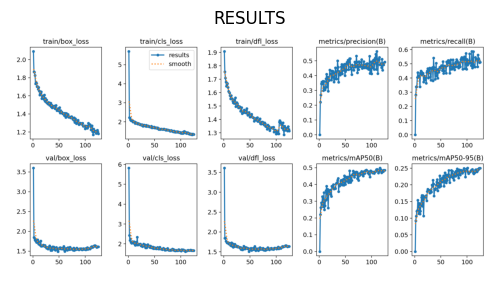

In [20]:
import cv2
import matplotlib.pyplot as plt
img_dir = "/kaggle/working/runs/detect/yolov11_effib0"  # adjust if needed
# Define image files to load
img_files = [
    "results.png"
]
# Plot grid
plt.figure(figsize=(15, 10))
for idx, img_name in enumerate(img_files):
    img_path = os.path.join(img_dir, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, idx + 1)
    plt.imshow(img)
    plt.title(img_name.replace(".png", "").replace("_", " ").upper())
    plt.axis("off")
plt.tight_layout()
plt.show()

In [21]:
import zipfile
zip_path = "/kaggle/working/yolov11_effib0_export.zip"
with zipfile.ZipFile(zip_path, 'w') as zipf:
    zipf.write("/kaggle/working/runs/detect/yolov11_effib0/results.png", arcname="results.png")
    zipf.write("/kaggle/working/runs/detect/yolov11_effib0/weights/best.pt", arcname="best.pt")
from IPython.display import FileLink
FileLink(zip_path)

/kaggle/working/yolov11_effib0_export.zip